# Evalulating k-means clustering

In [3]:
# essential libraries
import numpy as np
import matplotlib.pyplot as plt
# clustering model for unsupervised learning
from sklearn.cluster import KMeans
# for synthetic datasets. blobs for clustering and classification for classification
from sklearn.datasets import make_blobs, make_classification
# for evaluating unsupversied learning models
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
# for plotting voronoi figures
from scipy.spatial import Voronoi, voronoi_plot_2d
# for creating custom legend entries
from matplotlib.patches import Patch
# for creating color map 
from matplotlib import cm

<h3 style = 'color: red'>Clustering evaluation function</h3>

In [5]:
def evaluate_clustering(x, labels, n_clusters, ax = None, title_suffix = ''):
    '''
    evaluating a clustering model using silhouette scores and the davies-bouldin index.
    parameters:
    x (nparray): feature matrix
    labels (array-like): cluster labels assigned to each sample
    n_clusters (int): the number of clusters in the model
    ax: the subplot axes to plot on
    title_suffix (str): optional suffix for plot title
    returns:
    none: displays silhouette scores and a silhouette plot.
    '''
    if ax is None:
        ax = plt.gca()     # gca() is the function to get current axes
    # calculate silhouette scores
    silhouette_avg = silhouette_score(x, labels)
    sample_silhouette_values = silhouette_samples(x, labels)
    # plot silhouette analysis on the provided axis
    unique_labels = np.unique(labels)
    colormap = cm.tab10
    color_dict = {label: colormap(float(label) / n_clusters) for label in unique_labels}
    y_lower = 10
    for i in unique_labels:
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = color_dict[i]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor = color, ec = color, alpha = 0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    ax.set_title(f'Silhouette Score for {title_suffix} \n' + f'Average Silhouette: {silhouette_avg:.2f}')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.axvline(x = silhouette_avg, color = 'red', linestyle = '--')
    ax.set_xlim([-0.25, 1])
    ax.set_yticks([])

<h3 style = 'color: red'>Create synthetic data with 4 blobs to experiment with k-means clustering</h3>

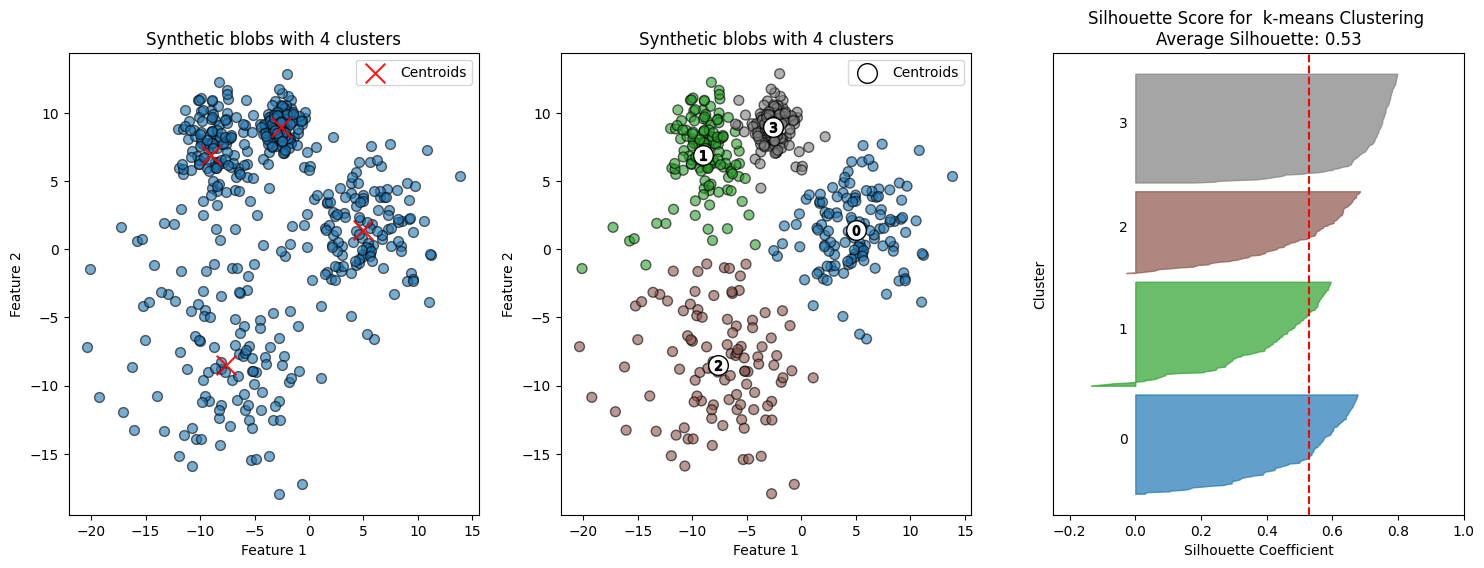

In [8]:
x, y = make_blobs(n_samples = 500, n_features = 2, centers = 4, cluster_std = [1.0, 3, 5, 2], random_state = 42)

# apply kmeans clustering
n_clusters = 4
kmeans = KMeans(n_clusters = n_clusters, random_state = 42)     # random_state is the seed for reproductivity, and init = 'k-means++' is default
y_kmeans = kmeans.fit_predict(x)

colormap = cm.tab10

# plot the blobs
plt.figure(figsize = (18, 6))
plt.subplot(1, 3, 1)
plt.scatter(x[:, 0], x[:, 1], s = 50, alpha = 0.6, ec = 'k')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c = 'red', s = 200, marker = 'x', alpha = 0.9, label = 'Centroids')
plt.title(f'Synthetic blobs with {n_clusters} clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# plot the clustering result
# create colors based on the predicted labels
colors = colormap(y_kmeans.astype(float) / n_clusters)
plt.subplot(1, 3, 2)
plt.scatter(x[:, 0], x[:, 1], c = colors, s = 50, alpha = 0.6, ec = 'k')
# label the clusters
centers = kmeans.cluster_centers_
# draw white circles at cluster centers
plt.scatter(centers[:, 0], centers[:, 1], marker = 'o', c = 'white', alpha = 1, s = 200, ec = 'k', label = 'Centroids')
# label the cluster number
for i, c in enumerate(centers):
    plt.scatter(c[0], c[1], marker = '$%d$' % i, alpha = 1, s = 50, ec = 'k')
plt.title(f'Synthetic blobs with {n_clusters} clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# evaluate the clustering
plt.subplot(1, 3, 3)
evaluate_clustering(x, y_kmeans, n_clusters, title_suffix = ' k-means Clustering')
plt.show()

<h3 style = 'color: red'>Cluster Stability</h3>

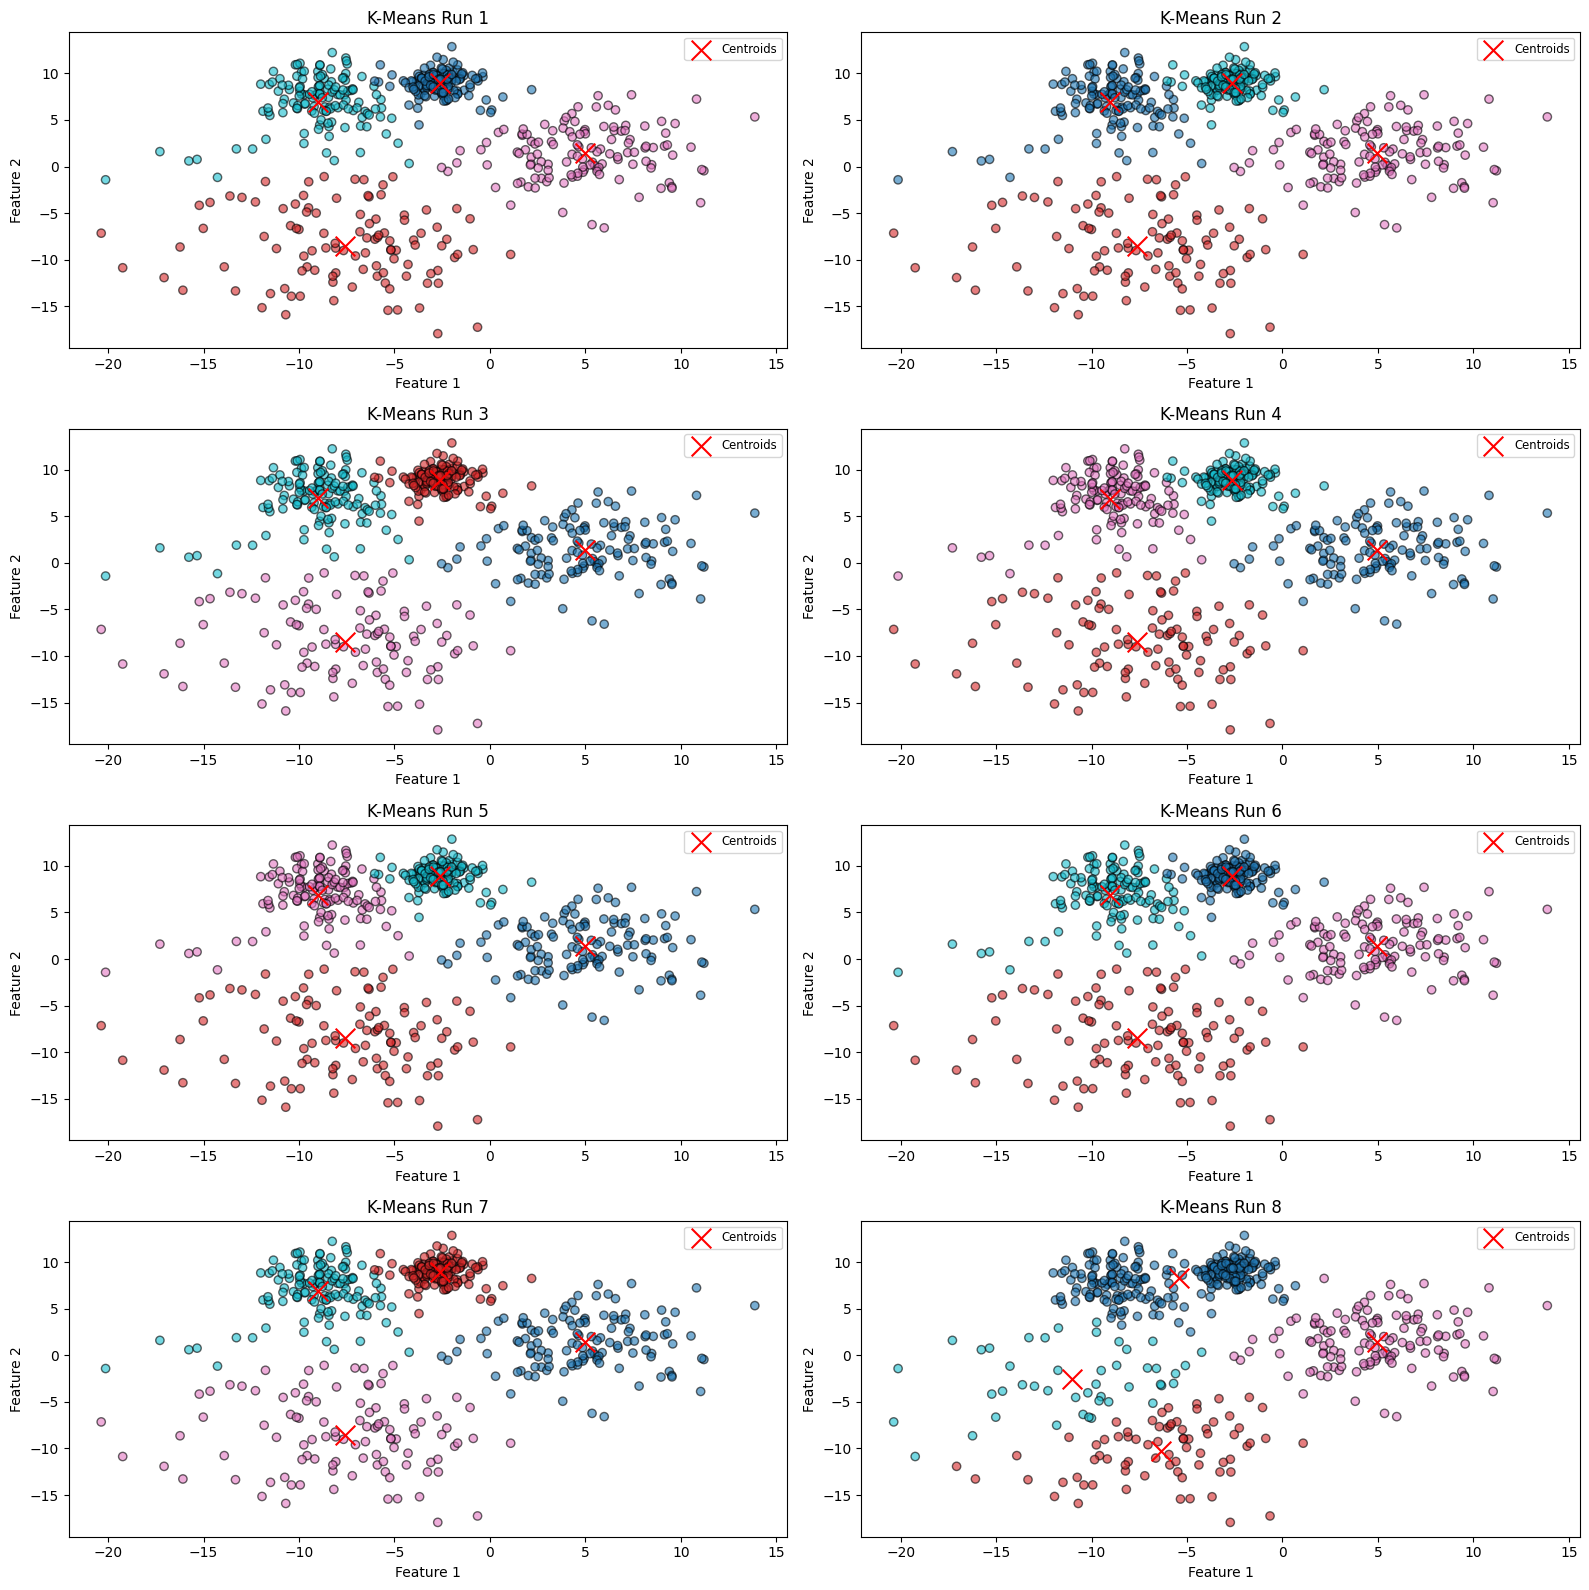

Run 1: Inertia = 7633.51
Run 2: Inertia = 7633.51
Run 3: Inertia = 7633.51
Run 4: Inertia = 7633.68
Run 5: Inertia = 7633.68
Run 6: Inertia = 7633.51
Run 7: Inertia = 7633.51
Run 8: Inertia = 8556.67


In [10]:
# number of runs for k-means with different random states
n_runs = 8
inertia_values = []
# calculate number of rows and columns needed for subplots
n_cols = 2
n_rows = -(-n_runs // n_cols)
plt.figure(figsize = (16, 16))
# run k-means multiple times with different random states
for i in range(n_runs):
    kmeans = KMeans(n_clusters = 4, random_state = None)
    kmeans.fit(x)
    inertia_values.append(kmeans.inertia_)
    # plot the clustering result
    plt.subplot(n_rows, n_cols, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c = kmeans.labels_, cmap = 'tab10', alpha = 0.6, ec = 'k')
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c = 'red', s = 200, marker = 'x', label = 'Centroids')
    plt.title(f'K-Means Run {i + 1}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(loc = 'upper right', fontsize = 'small')
plt.tight_layout()
plt.show()
# print inertia values
for i, inertia in enumerate(inertia_values, start = 1):
    print(f'Run {i}: Inertia = {inertia:.2f}')

<h3 style = 'color: red'>Number of clusters</h3>

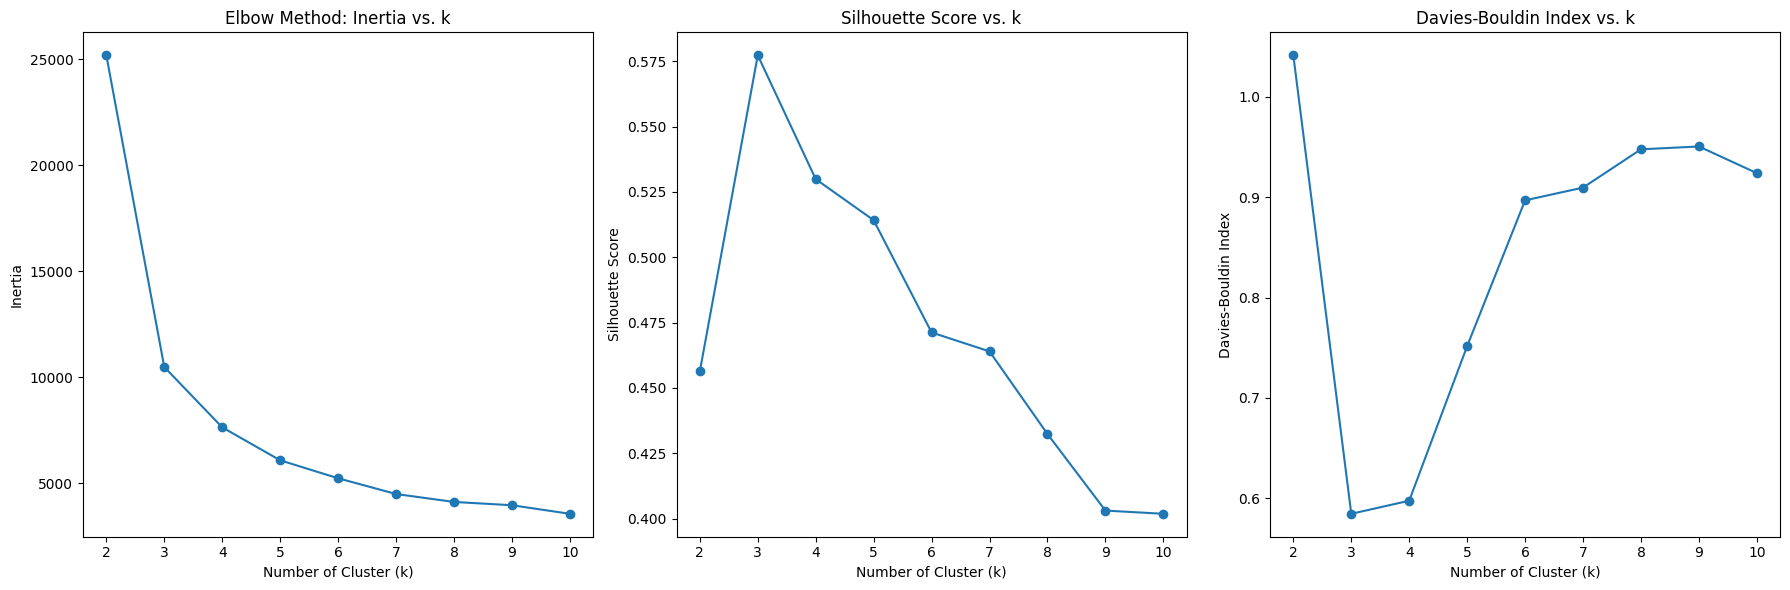

In [11]:
# range of k values to test
k_values = range(2, 11)
# store performance metrics
inertia_values = []
silhouette_scores = []
davies_bouldin_indices = []
for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state = 42)
    y_kmeans = kmeans.fit_predict(x)
    # calcuate and store metrics
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(x, y_kmeans))
    davies_bouldin_indices.append(davies_bouldin_score(x, y_kmeans))
# plot the inertia values (Elbow Method)
plt.figure(figsize = (18, 6))
plt.subplot(1, 3, 1)
plt.plot(k_values, inertia_values, marker = 'o')
plt.title('Elbow Method: Inertia vs. k')
plt.xlabel('Number of Cluster (k)')
plt.ylabel('Inertia')
# plot silhouette scores
plt.subplot(1, 3, 2)
plt.plot(k_values, silhouette_scores, marker = 'o')
plt.title('Silhouette Score vs. k')
plt.xlabel('Number of Cluster (k)')
plt.ylabel('Silhouette Score')
# plot Davies-Bouldin Index
plt.subplot(1, 3, 3)
plt.plot(k_values, davies_bouldin_indices, marker = 'o')
plt.title('Davies-Bouldin Index vs. k')
plt.xlabel('Number of Cluster (k)')
plt.ylabel('Davies-Bouldin Index')
plt.tight_layout()
plt.show()

<h3 style = 'color: red'>Plot the blobs and the clustering results for k = 3, 4, and 5</h3>

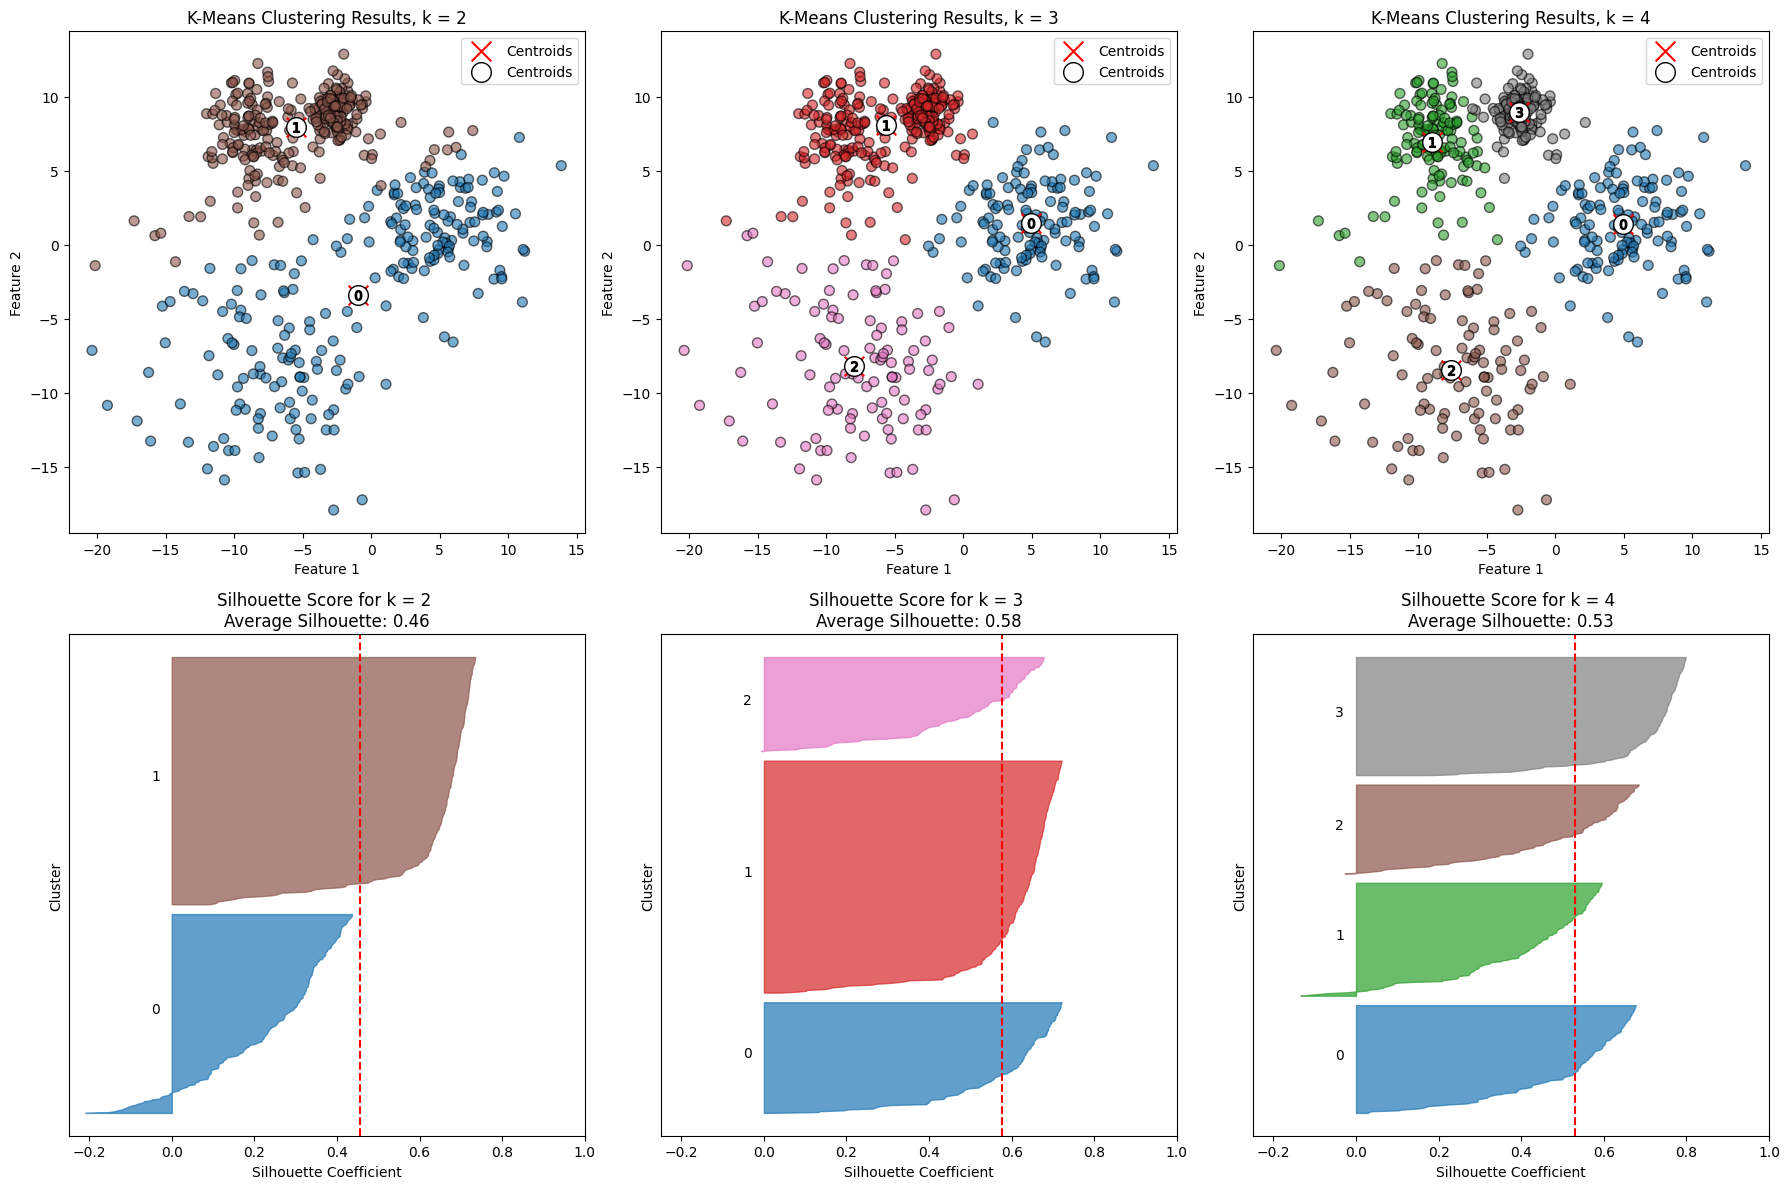

In [12]:
plt.figure(figsize = (18, 12))
colormap = cm.tab10
for i, k in enumerate([2, 3, 4]):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    y_kmeans = kmeans.fit_predict(x)
    # create colors based on the pedicted labels
    colors = colormap(y_kmeans.astype(float) / k)
    # scatter plot for each k in the first row (1, 2, 3)
    ax = plt.subplot(2, 3, i+1)
    ax.scatter(x[:, 0], x[:, 1], c = colors, s = 50, alpha = 0.6, ec = 'k')
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c = 'red', s = 200, marker = 'x', label = 'Centroids')
    # labeling the clusters
    centers = kmeans.cluster_centers_
    # draw white circles at cluster centers
    plt.scatter(centers[:, 0], centers[:, 1], marker = 'o', c = 'white', alpha = 1, s = 200, ec = 'k', label = 'Centroids')
    for i_, c in enumerate(centers):
        plt.scatter(c[0], c[1], marker = '$%d$' % i_, alpha = 1, s = 50, ec = 'k')
    ax.set_title(f'K-Means Clustering Results, k = {k}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
    # silhouette plot for each k in the second row
    ax2 = plt.subplot(2, 3, i+4)
    evaluate_clustering(x, y_kmeans, k, ax = ax2, title_suffix = f'k = {k}')
plt.tight_layout()
plt.show()

<h3 style = 'color: red'>Limitation of k-means: shape sensitivity</h3>

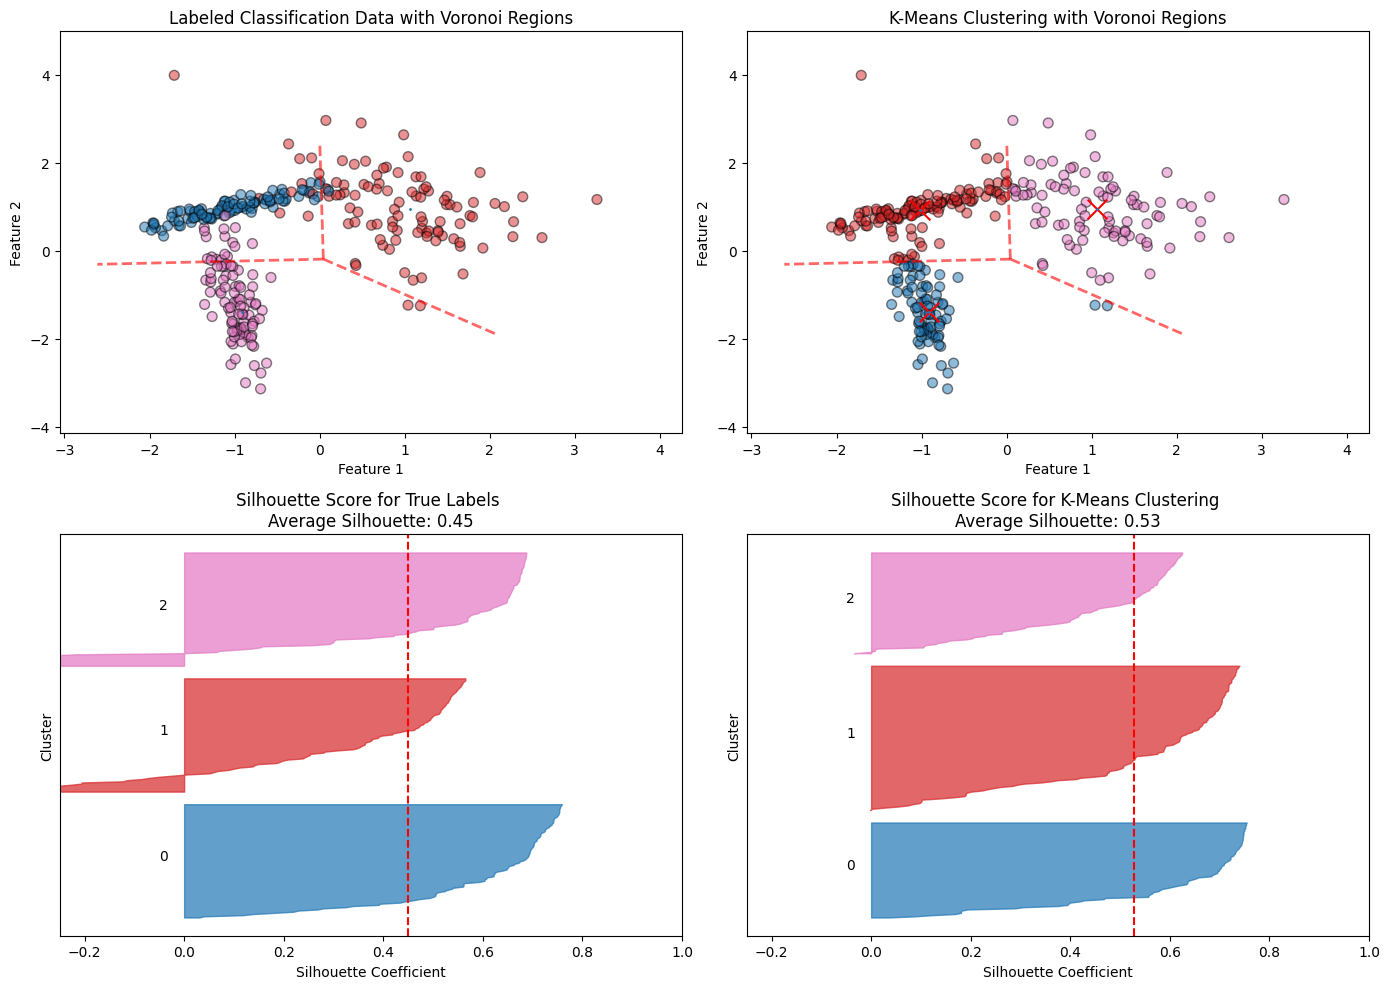

In [16]:
# generate synthetic classification data with no redundant (no noise), 300 data points, 2 features, each class for 1 cluster, and 3 classes
x, y_true = make_classification(n_samples = 300, n_features = 2, n_informative = 2, n_redundant = 0, n_clusters_per_class = 1,
                                n_classes = 3, random_state = 42)
# apply k-means clustering
kmeans = KMeans(n_clusters = 3, random_state = 42)
y_kmeans = kmeans.fit_predict(x)
centroids = kmeans.cluster_centers_
# compute the Voronoi diagram
vor = Voronoi(centroids)
# create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
# get consistent axis limits for all scatter plots
x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1
# first plot: plot the true labels with Voronoi regions
colormap = cm.tab10
colors_true = colormap(y_true.astype(float) / 3)
axes[0, 0].scatter(x[:, 0], x[:, 1], c = colors_true, s = 50, alpha = 0.5, ec = 'k')
voronoi_plot_2d(vor, ax = axes[0, 0], show_vertices = False, line_colors = 'red', line_width = 2, line_alpha = 0.6, point_size = 2)
axes[0, 0].set_title('Labeled Classification Data with Voronoi Regions')
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')
axes[0, 0].set_xlim(x_min, x_max)
axes[0, 0].set_ylim(y_min, y_max)
# second plot: call evaluate_clustering for true labels
evaluate_clustering(x, y_true, n_clusters = 3, ax = axes[1, 0], title_suffix = 'True Labels')
# third plot: plot k-means clustering results with Voronoi regions
colors_kmeans = colormap(y_kmeans.astype(float) / 3)
axes[0, 1].scatter(x[:, 0], x[:, 1], c = colors_kmeans, s = 50, alpha = 0.5, ec = 'k')
axes[0, 1].scatter(centroids[:, 0], centroids[:, 1], c = 'red', s = 200, marker = 'x', label = 'Centroids')
voronoi_plot_2d(vor, ax = axes[0, 1], show_vertices = False, line_colors = 'red', line_width = 2, line_alpha = 0.6, point_size = 2)
axes[0, 1].set_title('K-Means Clustering with Voronoi Regions')
axes[0, 1].set_xlabel('Feature 1')
axes[0, 1].set_ylabel('Feature 2')
axes[0, 1].set_xlim(x_min, x_max)
axes[0, 1].set_ylim(y_min, y_max)
# forth plot: call evaluate clustering for k-means labels
evaluate_clustering(x, y_kmeans, n_clusters = 3, ax = axes[1, 1], title_suffix = 'K-Means Clustering')
plt.tight_layout()
plt.show()